In [6]:
library(tidyverse)
library(vroom)
library(data.table)
library(future.apply)

####### Systematic processing. ########
out_dir <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/"
# Create outdir.
dir.create(out_dir, showWarnings = FALSE)


# First we look at all the samples that are available. 
input_dir1 <- "/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly/"
input_dir2 <- "/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer/"

# Get all full filenames in all the input dirs. 
cellline_filenames1 <- list.files(path = input_dir1, pattern = "umi_dedup_fine_grained_idx.csv$", full.names = TRUE)
cellline_filenames2 <- list.files(path = input_dir2, pattern = "umi_dedup_fine_grained_idx.csv$", full.names = TRUE)

# Make a df of these filenames.
cellline_paths <- data.frame(filename = c(cellline_filenames1, cellline_filenames2))
cellline_paths <- cellline_paths %>% 
  mutate(basename = basename(filename)) %>%
  mutate(sample = str_extract(basename(filename), ".+(?=_umi_dedup)")) %>%
  mutate(condition = str_extract(sample, "^.+(?=-rep\\d)")) %>% 
  # Strip satmutv2_ from the condition.
  mutate(rep_old = str_extract(basename(filename), "rep\\d")) %>%
  mutate(rep_new = rep_old) %>% 
  mutate(sample_new = paste0(condition, "-", rep_new))



In [5]:
cellline_paths

filename,basename,sample,condition,rep_old,rep_new,sample_new
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-A375-rep1_S1_umi_dedup_fine_grained_idx.csv,KELLYspecific-A375-rep1_S1_umi_dedup_fine_grained_idx.csv,KELLYspecific-A375-rep1_S1,KELLYspecific-A375,rep1,rep1,KELLYspecific-A375-rep1
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-A375-rep2_S2_umi_dedup_fine_grained_idx.csv,KELLYspecific-A375-rep2_S2_umi_dedup_fine_grained_idx.csv,KELLYspecific-A375-rep2_S2,KELLYspecific-A375,rep2,rep2,KELLYspecific-A375-rep2
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-A375-rep3_S3_umi_dedup_fine_grained_idx.csv,KELLYspecific-A375-rep3_S3_umi_dedup_fine_grained_idx.csv,KELLYspecific-A375-rep3_S3,KELLYspecific-A375,rep3,rep3,KELLYspecific-A375-rep3
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-HEK-rep1_S4_umi_dedup_fine_grained_idx.csv,KELLYspecific-HEK-rep1_S4_umi_dedup_fine_grained_idx.csv,KELLYspecific-HEK-rep1_S4,KELLYspecific-HEK,rep1,rep1,KELLYspecific-HEK-rep1
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-HEK-rep2_S5_umi_dedup_fine_grained_idx.csv,KELLYspecific-HEK-rep2_S5_umi_dedup_fine_grained_idx.csv,KELLYspecific-HEK-rep2_S5,KELLYspecific-HEK,rep2,rep2,KELLYspecific-HEK-rep2
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-HEK-rep3_S6_umi_dedup_fine_grained_idx.csv,KELLYspecific-HEK-rep3_S6_umi_dedup_fine_grained_idx.csv,KELLYspecific-HEK-rep3_S6,KELLYspecific-HEK,rep3,rep3,KELLYspecific-HEK-rep3
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-KELLY-rep1_S7_umi_dedup_fine_grained_idx.csv,KELLYspecific-KELLY-rep1_S7_umi_dedup_fine_grained_idx.csv,KELLYspecific-KELLY-rep1_S7,KELLYspecific-KELLY,rep1,rep1,KELLYspecific-KELLY-rep1
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-KELLY-rep2_S8_umi_dedup_fine_grained_idx.csv,KELLYspecific-KELLY-rep2_S8_umi_dedup_fine_grained_idx.csv,KELLYspecific-KELLY-rep2_S8,KELLYspecific-KELLY,rep2,rep2,KELLYspecific-KELLY-rep2
/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-KELLY-rep3_S9_umi_dedup_fine_grained_idx.csv,KELLYspecific-KELLY-rep3_S9_umi_dedup_fine_grained_idx.csv,KELLYspecific-KELLY-rep3_S9,KELLYspecific-KELLY,rep3,rep3,KELLYspecific-KELLY-rep3


In [7]:
# Extract all metrics and append to cellline_paths
metrics_list <- lapply(1:nrow(cellline_paths), function(i) {
  filename_full <- cellline_paths$filename[i]
  sample_name <- cellline_paths$sample[i]
  filename_dir <- dirname(filename_full)
  stats_log_path <- file.path(filename_dir, paste0(sample_name, "_stats_log_fine_grained_idx.txt"))
  
  if (file.exists(stats_log_path)) {
    stats_log <- read_csv(stats_log_path, col_names = FALSE)
    colnames(stats_log) <- c("metric", "count")
    
    # Convert metrics to a named list
    metric_values <- as.list(setNames(stats_log$count, stats_log$metric))
    return(metric_values)
  } else {
    return(NULL)
  }
})

# Combine metrics with cellline_paths
metrics_df <- bind_rows(metrics_list) %>%
  mutate_all(as.character)  # Ensure consistent data type

cellline_paths <- bind_cols(cellline_paths, metrics_df)

# Filter out samples that have < 1M aligned reads.
cellline_paths_filtered <- cellline_paths %>% 
  mutate(total_aligned_reads = as.integer(total_aligned_reads)) %>% 
  filter(total_aligned_reads >= 1e6) 

# Write this metadata to file.
write_csv(cellline_paths_filtered, "/mnt/dawnccle2/melange/process_fastq_250221/13_denovo_R2/cellline_sample_metadata_denovoR2.csv")


Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","

In [8]:
# This is the new version of normalization based on "Version 3" math.
normalize_all_non_included_reads <- function(df, chimeric_rate) {
  df_with_stats <- df %>% 
    mutate(is_included = ifelse(mode == "INCLUDED", TRUE, FALSE)) %>% 
    group_by(index) %>% 
    mutate(
      total_count = sum(count),
      total_included_count = sum(count * is_included, na.rm = TRUE) ,
      total_not_included_count = sum(count * !is_included, na.rm = TRUE)
    ) %>% 
    ungroup()
    
  df_not_included <- df_with_stats %>% 
    filter(!is_included) %>% 
    group_by(index) %>% 
    mutate(read_frac = count / sum(count)) %>% 
    ungroup() 
  
  df_not_included <- df_not_included %>%
    mutate(count_scaled = (total_not_included_count - chimeric_rate* total_included_count)/(1+ chimeric_rate) * read_frac) %>%
    # Convert all to integer.
    mutate(count_scaled = as.integer(count_scaled)) %>% 
    # If value < 0, set to 0.
    mutate(count_scaled = ifelse(count_scaled < 0, 0, count_scaled)) %>% 
    select(-is_included, -total_count, -total_included_count, -total_not_included_count, -read_frac)
  
  return(df_not_included)
}



# Parallel version of merge_offsets_to_ref.
merge_offsets_to_ref_parallel <- function(df, workers = 64) {
  plan(multisession, workers = workers)

  # Preprocess and split
  df_sep <- df %>%
    separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = FALSE) %>%
    mutate(index_full = paste0(index, "_", offset_initial, "_", design)) %>% 
    mutate(across(c(upstream_offset, downstream_offset, const_offset), as.integer)) %>%
    as.data.table()

  cat("done separating\n")

  # Split by index (parallelizable units)
  df_list <- split(df_sep, by = "index_full")
  # Greedy merge function (same as before, per index)
  greedy_merge_index <- function(df_idx) {
    setorder(df_idx, -count)
    merged <- data.table()

    while (nrow(df_idx) > 0) {
      anchor <- df_idx[1]
      u0 <- anchor$upstream_offset
      d0 <- anchor$downstream_offset
      c0 <- anchor$const_offset

      neighbors <- df_idx[
        upstream_offset %between% c(u0 - 1, u0 + 1) &
        downstream_offset %between% c(d0 - 1, d0 + 1)
      ]

      anchor$count <- sum(neighbors$count)
      merged <- rbind(merged, anchor, use.names = TRUE)
      df_idx <- fsetdiff(df_idx, neighbors)
    }

    return(merged)
  }

  # Run in parallel across indices
  results <- future_lapply(df_list, greedy_merge_index)

  # Combine and clean
  out <- rbindlist(results)
  out[, c("upstream_offset", "downstream_offset", "const_offset", "index_full") := NULL]
  return(out[])
}

# Get all unique sample_new names.
unique_samples <- cellline_paths_filtered %>% group_by(sample_new) %>% summarise(n=n()) %>% ungroup() 
unique_sample_names <- unique(cellline_paths_filtered$sample_new)

# merge_offsets_to_ref_parallel(tmp_included_sequences_only)


In [9]:
unique_sample_names


[1] "KELLYspecific-A375-rep1"      "KELLYspecific-A375-rep2"     
 [3] "KELLYspecific-A375-rep3"      "KELLYspecific-HEK-rep1"      
 [5] "KELLYspecific-HEK-rep2"       "KELLYspecific-HEK-rep3"      
 [7] "KELLYspecific-KELLY-rep1"     "KELLYspecific-KELLY-rep2"    
 [9] "KELLYspecific-KELLY-rep3"     "CANCERspecific-CH3-1-A1-rep1"
[11] "CANCERspecific-CH3-1-A1-rep2" "CANCERspecific-RBM5-A2-rep1" 
[13] "CANCERspecific-RBM5-A2-rep2"

In [11]:
# Merge offsets. For each index, take the biggest offset, and then assign the +/-1 offset counts to the counts of the biggest offset.
# Iterate until there are no more offsets to merge.
merge_offsets_to_ref <- function(df){
  print("Merging offsets to ref")
  print(head(df))
  df_sep <- df %>% 
  ungroup() %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = FALSE) %>% 
  mutate(upstream_offset = as.integer(upstream_offset), downstream_offset = as.integer(downstream_offset), const_offset = as.integer(const_offset)) %>% 
  mutate(index_full = paste0(index, "_", offset_initial, "_", design))
  cat("done separating\n")
  unique_indices <- unique(df_sep$index_full)
  print(head(unique_indices))
  new_df <- data.frame()
  for (idx in unique_indices){
    df_tmp_idx <- df_sep %>% 
      filter(index_full == idx) %>% 
      arrange(desc(count))
    # cat("################## before merging dataframe for index:", idx, "\n")
    # print(df_tmp_idx, n = nrow(df_tmp_idx), width = Inf)
    new_df_tmp_idx <- data.frame()
    while (nrow(df_tmp_idx) > 0){
      max_offset_row <- df_tmp_idx %>% slice(1)
      max_offset_val_upstream <- max_offset_row$upstream_offset
      max_offset_val_downstream <- max_offset_row$downstream_offset
      # Get all possible offses for upstream_offset, downstream_offset. +/- 1.
      possible_offset_rows <- df_tmp_idx %>% 
      filter((upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream - 1))
      # Merge the counts for these possible_offset_rows. And assign the count to the max_offset_row.
      merged_counts <- possible_offset_rows %>% pull(count) %>% sum()
      max_offset_row$count <- merged_counts
      # Remove the possible_offset_rows from df_tmp_idx. Need to be the exact pairs that are in possible_offset_rows.
      # Filter out the exact pairs that are in possible_offset_rows
      df_tmp_idx <- anti_join(df_tmp_idx, possible_offset_rows, 
                             by = c("upstream_offset", "downstream_offset", "const_offset"))
      # Add the max_offset_row to new_df_tmp_idx.
      new_df_tmp_idx <- bind_rows(new_df_tmp_idx, max_offset_row)
    }
    # cat("Final merged dataframe for index:", idx, "\n")
    #print(new_df_tmp_idx)
    new_df <- bind_rows(new_df, new_df_tmp_idx)
  }
  # Remove the upstream_offset, downstream_offset, const_offset columns.
  new_df <- new_df %>% select(-upstream_offset, -downstream_offset, -const_offset, -index_full)
  return(new_df)
}

for (sample_tmp in unique_sample_names){
  # Get all the filepaths with that sample name.
  sample_filepaths <- cellline_paths_filtered %>% filter(sample_new == sample_tmp) %>% pull(filename)
  tmp_out <- data.frame()
  for (filepath in sample_filepaths) {
    base::print(paste("Processing", filepath))
    # Get the parent folder name from the filepath. (not full path)
    parent_folder <- basename(dirname(filepath))
    # Get basename and strip _umi_dedup_fine_grained_idx.csv
    filename_basename <- basename(filepath) %>% str_extract(".+(?=_umi_dedup_fine_grained_idx.csv)")
    
    # Read in the tsv file.
    tmp <- vroom(filepath, id = "filename", delim = ",") %>% 
    filter(grepl("R2design", index))
    
    # Get chimeric rate from the metadata table. 
    chimeric_rate <- cellline_paths_filtered %>% 
      filter(filename == filepath) %>% 
      pull(perc_chimera_reads)
    base::print(paste("chimeric_rate:", chimeric_rate))
    
    # Separate the "index" column into id, mode, offset, insert_size based on __ separator.
    tmp_to_ref <- tmp %>% 
      separate(index, into = c("index", "offset_initial", "design", "mode", "offset" ,"insert_size"), sep = "__", remove = FALSE) %>% 
      select(-insert_size)
    
    # Split into included (need offset merging), and everything else (need adjustment).
    # We just directly adjust the counts for non-included as count_scaled = count * (1 - chimeric_rate).
    tmp_included_sequences_only <- tmp_to_ref %>% filter(mode == "INCLUDED") 
    tmp_included_merged_offsets <- merge_offsets_to_ref(tmp_included_sequences_only) %>% mutate(count_scaled = count)
    # Normalize the non-included reads.  
    tmp_everything_else <- tmp_to_ref %>% filter(mode != "INCLUDED") %>% mutate(count_scaled = count)
    
    tmp_final <- bind_rows(tmp_included_merged_offsets, tmp_everything_else)

    # Write tmp_final to file.
    fwrite(tmp_final, file.path(out_dir, paste0(parent_folder, "-individual-", filename_basename, "_umi_dedup_normalized_tmp.tsv")))

    tmp_out <- bind_rows(tmp_out, tmp_final) %>%
      group_by(filename, index, offset_initial, design, mode, offset) %>% 
      summarise(count = sum(count), count_scaled = sum(count_scaled))
  }
  
  # Write to outdir. 
  base::print(paste("Writing to", file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized.tsv"))))
  fwrite(tmp_out, file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized.tsv")))
}

[1] "Processing /mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-A375-rep1_S1_umi_dedup_fine_grained_idx.csv"


Rows: 17256 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): index
dbl (1): count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "chimeric_rate: 0.160236025418363"
[1] "Merging offsets to ref"
# A tibble: 6 × 7
  filename                        index offset_initial design mode  offset count
  <chr>                           <chr> <chr>          <chr>  <chr> <chr>  <dbl>
1 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… -1:0:0     1
2 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… -1:0:0     3
3 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… -2:0:0     1
4 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… 0:-1:0     1
5 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… 0:-1:0     1
6 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… 0:-2:0     1
done separating
[1] "ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330_0:0:0_R2design0"                   
[2] "ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330_0:0:0_vae_Kelly_1_to_pos_R2design1"
[3

`summarise()` has grouped output by 'filename', 'index', 'offset_initial',
'design', 'mode'. You can override using the `.groups` argument.


[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2//KELLYspecific-A375-rep1_umi_dedup_normalized.tsv"
[1] "Processing /mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_kelly//KELLYspecific-A375-rep2_S2_umi_dedup_fine_grained_idx.csv"


...

[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2//CANCERspecific-RBM5-A2-rep1_umi_dedup_normalized.tsv"
[1] "Processing /mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-RBM5-A2-rep2_S11_umi_dedup_fine_grained_idx.csv"


Rows: 41508 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): index
dbl (1): count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "chimeric_rate: 0.143732455320763"
[1] "Merging offsets to ref"
# A tibble: 6 × 7
  filename                        index offset_initial design mode  offset count
  <chr>                           <chr> <chr>          <chr>  <chr> <chr>  <dbl>
1 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… -44:0…    15
2 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R2des… INCL… 0:0:0      5
3 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_c… INCL… -1:0:0     4
4 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_c… INCL… -1:0:0     4
5 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_c… INCL… 0:-1:0     1
6 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_c… INCL… 0:0:0     28
done separating
[1] "ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115_0:0:0_R2design0"                              
[2] "ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115_0:0:0_vae_cancer_U2AF

`summarise()` has grouped output by 'filename', 'index', 'offset_initial',
'design', 'mode'. You can override using the `.groups` argument.


[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2//CANCERspecific-RBM5-A2-rep2_umi_dedup_normalized.tsv"


# Merge the samples into 1 file

In [12]:
# Merge samples into one file. 
library(tidyverse)
library(vroom)
library(data.table)

out_dir <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/"
dir.create(out_dir, showWarnings = FALSE)

process_samples <- function(input_dir, sample_type, out_dir) {
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
  
  input_filenames <- list.files(path = input_dir, pattern = "umi_dedup_normalized.tsv$", full.names = TRUE)
  
  # Precompute sample and condition for each file
  file_metadata <- tibble(
    filename = input_filenames,
    sample = basename(input_filenames) %>% str_extract(".+(?=_umi_dedup_normalized.tsv)"),
    condition = str_extract(basename(input_filenames), "^.+(?=-rep\\d)")
  )
  
  # Read data and attach metadata
  all_files_df <- map_dfr(seq_along(file_metadata$filename), function(i) {
    df <- vroom(file_metadata$filename[i], delim = ",")
    df$sample <- file_metadata$sample[i]
    df$condition <- file_metadata$condition[i]
    df
  })
  
  fwrite(all_files_df, file.path(out_dir, paste0(sample_type, "_all_samples_raw_counts.csv")))
}

# Define input and output directories
input_output_mapping <- list(
  list(input_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/", 
       sample_type = "denovoR2", 
       out_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/")
)

# Process each sample type
walk(input_output_mapping, ~process_samples(.x$input_dir, .x$sample_type, .x$out_dir))

Rows: 22680 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): filename, index, offset_initial, design, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 23319 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): filename, index, offset_initial, design, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 28374 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): filename, index, offset_initial, design, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification

# Now analyze the data

In [3]:
raw_df <- read.csv("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/denovoR2_all_samples_raw_counts.csv")
head(raw_df)

# Get the unique conditions.
unique_conditions <- unique(raw_df$condition)
print(unique_conditions)

# Get the unique samples.
unique_samples <- unique(raw_df$sample)
print(unique_samples)

# Get the unique indices.

,filename,index,offset_initial,design,mode,offset,count,count_scaled,sample,condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,INCLUDED,-44:0:0,9,9,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
2,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,INCLUDED,0:0:0,1,1,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
3,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,SKIPPED,0,54,54,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
4,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,UNSPLICED,0,8,8,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
5,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,UNSPLICED,1,1,1,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
6,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,UNSPLICED,113,27,27,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1


[1] "CANCERspecific-CH3-1-A1" "CANCERspecific-RBM5-A2" 
[3] "KELLYspecific-A375"      "KELLYspecific-HEK"      
[5] "KELLYspecific-KELLY"    
 [1] "CANCERspecific-CH3-1-A1-rep1" "CANCERspecific-CH3-1-A1-rep2"
 [3] "CANCERspecific-RBM5-A2-rep1"  "CANCERspecific-RBM5-A2-rep2" 
 [5] "KELLYspecific-A375-rep1"      "KELLYspecific-A375-rep2"     
 [7] "KELLYspecific-A375-rep3"      "KELLYspecific-HEK-rep1"      
 [9] "KELLYspecific-HEK-rep2"       "KELLYspecific-HEK-rep3"      
[11] "KELLYspecific-KELLY-rep1"     "KELLYspecific-KELLY-rep2"    
[13] "KELLYspecific-KELLY-rep3"    


In [4]:
raw_df_clean <- raw_df %>%
    mutate(index_offset = paste0(index, "__", offset_initial)) %>% 
    select(-filename, - index, - offset_initial) %>%
    filter(mode %in% c("INCLUDED", "SKIPPED")) %>% 
    group_by(sample, condition, index_offset, mode, offset, design) %>%
    summarise(count = sum(count)) %>% 
    arrange(sample, condition, index_offset, design)
head(raw_df_clean)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode', 'offset'. You can override using the `.groups` argument.


sample,condition,index_offset,mode,offset,design,count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,-44:0:0,R2design0,9
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,0:0:0,R2design0,1
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,SKIPPED,0,R2design0,54
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,-2:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,1
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,703
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,2:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,2


In [5]:
raw_df_to_psi <- raw_df_clean %>% 
    group_by(sample, condition, index_offset, mode, design) %>%
    summarise(count = sum(count)) %>% 
    ungroup() %>% 
    pivot_wider(names_from = mode, values_from = count, values_fill = 0) %>%
    mutate(total_counts = INCLUDED + SKIPPED) %>%
    filter(total_counts >= 30) %>%
    mutate(PSI = INCLUDED / total_counts)

head(raw_df_to_psi)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode'. You can override using the `.groups` argument.


sample,condition,index_offset,design,INCLUDED,SKIPPED,total_counts,PSI
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,R2design0,10,54,64,0.15625000
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,719,692,1411,0.50956768
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design4,64,515,579,0.11053541
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design5,1,77,78,0.01282051
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design6,4,79,83,0.04819277
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design7,77,255,332,0.23192771


`summarise()` has grouped output by 'condition', 'index_offset'. You can
override using the `.groups` argument.


,KELLYspecific-A375,KELLYspecific-HEK,KELLYspecific-KELLY
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___R2design0,0.9442034587,0.934651978,0.9641113527
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design1,0.0023725402,0.001518528,0.0147895617
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design10,0.0000000000,0.000000000,0.0050386670
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design2,0.0017299657,0.001345044,0.0008996739
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design3,0.0008840896,0.001501590,0.0022412080
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design4,0.0012515409,0.001263872,0.0016759420


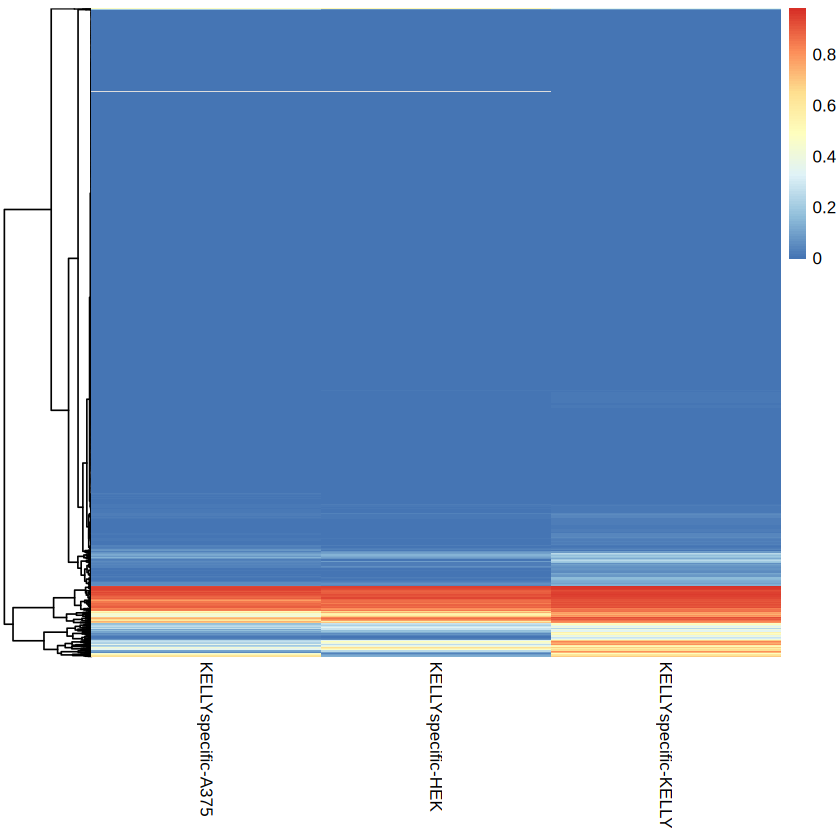

In [6]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)

# Look at the kelly sequences only. 

raw_df_to_psi_kelly <- raw_df_to_psi %>% 
    filter(grepl("KELLYspecific", condition))
raw_df_to_psi_kelly <- raw_df_to_psi_kelly %>% 
    # filter(design != "R2design0") %>% 
    group_by(condition, index_offset, design) %>% 
    summarise(PSI = mean(PSI)) %>% 
    ungroup() %>% 
    select(condition, index_offset, design, PSI) %>% 
    pivot_wider(names_from = condition, values_from = PSI) %>% 
    mutate(index_offset_design = paste0(index_offset, "___", design))

# Convert to matrix. 
psi_kelly_mat <- as.matrix(raw_df_to_psi_kelly %>% select(-index_offset_design, -index_offset, -design))
rownames(psi_kelly_mat) <- raw_df_to_psi_kelly$index_offset_design

pheatmap(psi_kelly_mat, cluster_rows = TRUE, cluster_cols = FALSE, show_colnames = TRUE, show_rownames = FALSE)

head(psi_kelly_mat)

In [6]:
raw_df_to_psi_kelly_filtered <- raw_df_to_psi_kelly %>% 
    mutate(KELLY_PSI_minus_HEK_PSI = `KELLYspecific-KELLY`/`KELLYspecific-HEK`) %>% 
    mutate(KELLY_PSI_minus_A375_PSI = `KELLYspecific-KELLY`/`KELLYspecific-A375`) 

options(repr.plot.width=12, repr.plot.height=12)
ggplot(raw_df_to_psi_kelly_filtered, aes(x = KELLY_PSI_minus_HEK_PSI, y = KELLY_PSI_minus_A375_PSI)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    theme_minimal() 

nrow(raw_df_to_psi_kelly)

# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)


# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)

ERROR: Error: object 'raw_df_to_psi_kelly' not found


In [1]:
# raw_df_to_psi_kelly %>% filter(grepl("Kelly_1_to_neg", index_offset_design))

# Now look at cancer specific 

In [14]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)

# Look at the kelly sequences only. 

raw_df_to_psi_cancer <- raw_df_to_psi %>% 
    filter(grepl("CANCERspecific", condition))
# raw_df_to_psi_cancer 

raw_df_to_psi_cancer <- raw_df_to_psi_cancer %>% 
    filter(design != "R2design0") %>% 
    group_by(condition, index_offset, design) %>% 
    summarise(PSI = mean(PSI)) %>% 
    ungroup() %>% 
    select(condition, index_offset, design, PSI) %>% 
    pivot_wider(names_from = condition, values_from = PSI) %>% 
    mutate(index_offset_design = paste0(index_offset, "___", design))

# Convert to matrix. 
# psi_cancer_mat <- as.matrix(raw_df_to_psi_cancer %>% select(-index_offset_design, -index_offset, -design))
# rownames(psi_cancer_mat) <- raw_df_to_psi_cancer$index_offset_design

# pheatmap(psi_cancer_mat, cluster_rows = FALSE, cluster_cols = FALSE, show_colnames = TRUE, show_rownames = FALSE)

# # head(psi_cancer_mat)
# raw_df_to_psi_cancer

`summarise()` has grouped output by 'condition', 'index_offset'. You can
override using the `.groups` argument.


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 67 rows containing non-finite outside the scale range (`stat_bin()`).”


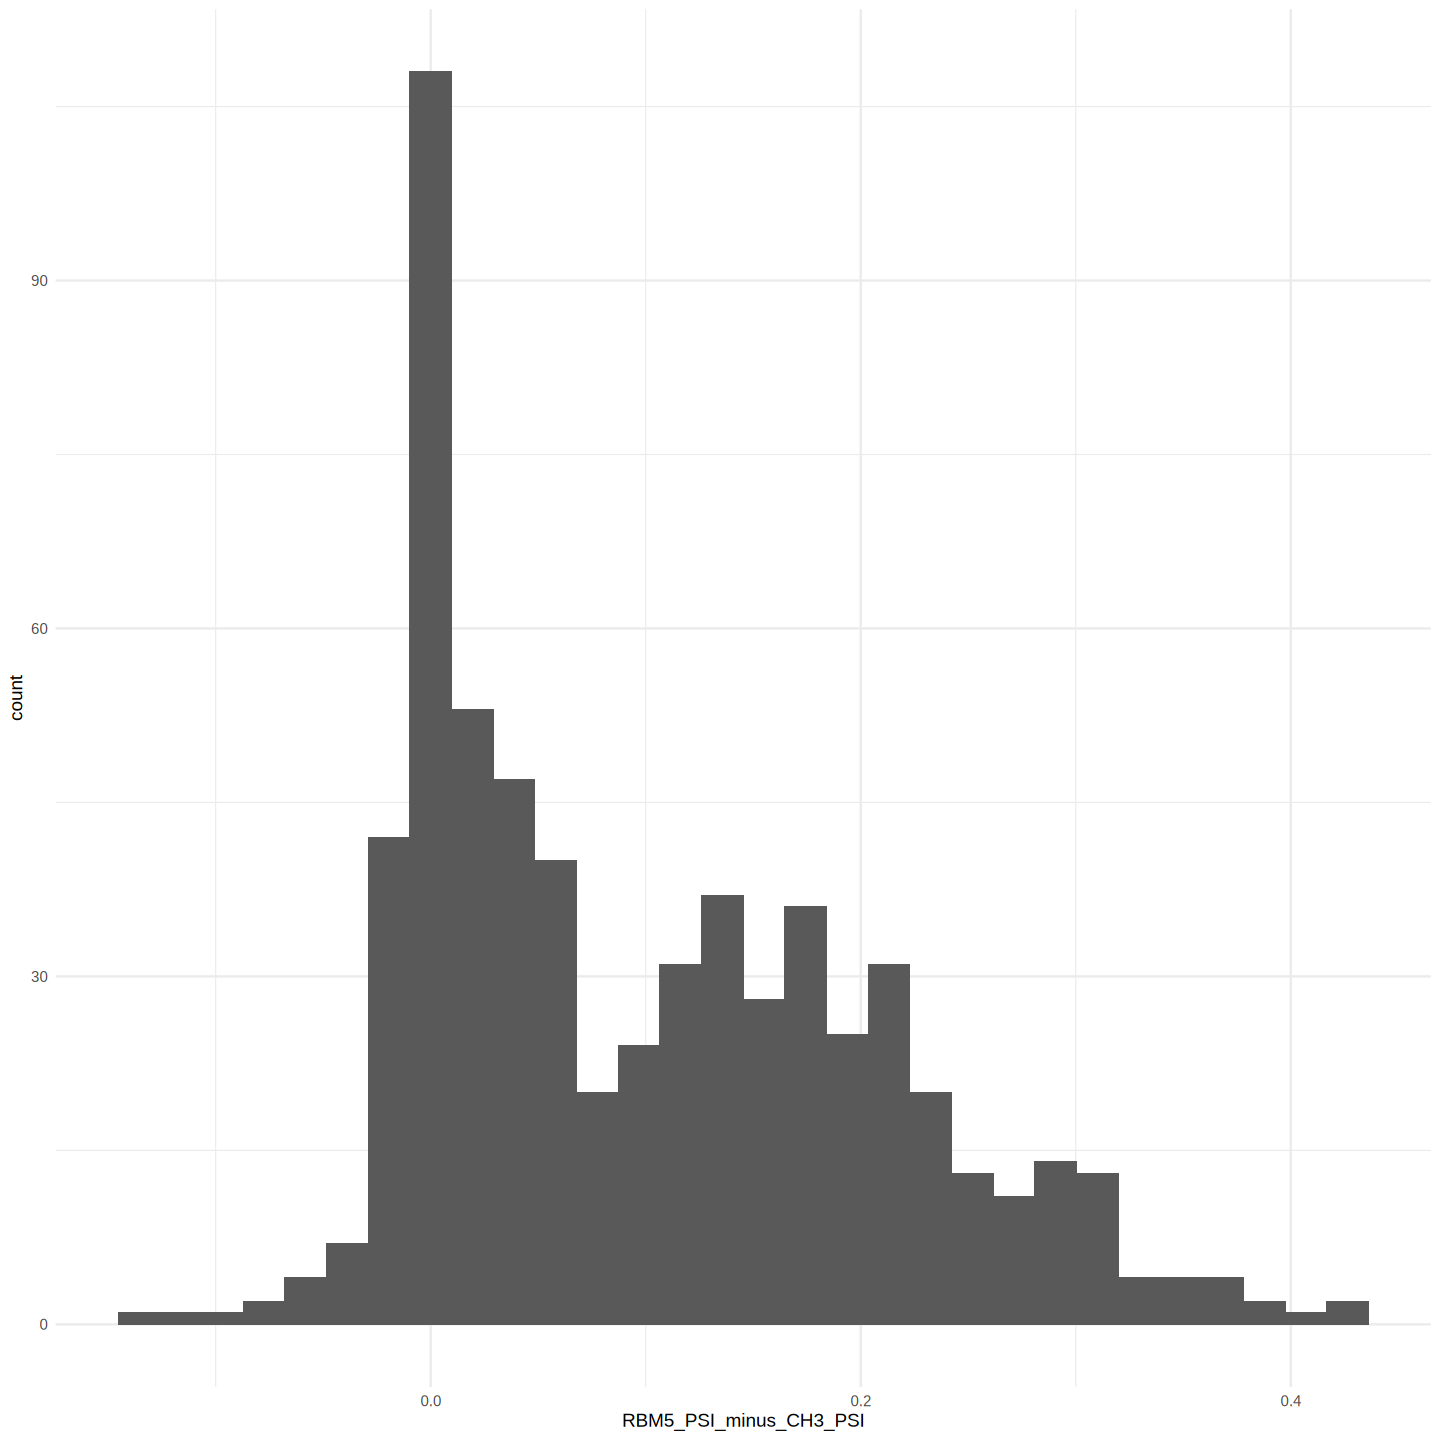

In [16]:
raw_df_to_psi_cancer_filtered <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_RBM5_0_to_pos",design)) %>% 
    mutate(RBM5_PSI_minus_CH3_PSI = `CANCERspecific-RBM5-A2` - `CANCERspecific-CH3-1-A1`)  %>%
    mutate(RBM5_PSI_FC_CH3_PSI = `CANCERspecific-RBM5-A2` / `CANCERspecific-CH3-1-A1`)


filtered_df <- raw_df_to_psi_cancer_filtered %>% 
    filter(abs(RBM5_PSI_minus_CH3_PSI) > 0.2)

options(repr.plot.width=12, repr.plot.height=12)
ggplot(raw_df_to_psi_cancer_filtered, aes(x = RBM5_PSI_minus_CH3_PSI)) +
    geom_histogram() +
    # geom_vline(xintercept = 0, color = "red") +
    theme_minimal() 

# filtered_df %>% arrange(desc(RBM5_PSI_FC_CH3_PSI))

# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)


# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)




In [34]:
raw_df_to_psi_cancer %>% filter(index_offset == "ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0")

index_offset,design,CANCERspecific-CH3-1-A1,CANCERspecific-RBM5-A2,index_offset_design
<chr>,<chr>,<dbl>,<dbl>,<chr>
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,R2design0,0.975486049,0.970393416,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___R2design0
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design1,0.000000000,0.005554524,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design1
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design2,0.062463147,0.368349979,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design2
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design3,0.023473933,0.167485232,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design3
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design4,0.020140381,0.174959838,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design4
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design5,0.002743489,0.003079577,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design5
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design7,0.098172020,0.433026942,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design7
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design8,0.252542865,0.664171657,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design8
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_pos_R2design10,0.179336735,0.301470588,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_pos_R2design10
